In [2]:
from pathlib import Path
from clearit.config import OUTPUTS_DIR
from clearit.metrics.gather_scatter_data import (
    prepare_scatter_dataframe_single_patient_networks,
)
from clearit.plotting.scatter import scatter_performance_vs_rank
from clearit.plotting.utils import build_single_patient_entries

In [3]:
# Build entries
entries = build_single_patient_entries(
    patient_start=1,
    patient_end=47,
    test_start_id=412,
    dataset_label="TNBC1-MxIF8",
)

# Load image statistics
image_stats_csv = Path(
    OUTPUTS_DIR, "ranking", "TNBC1-MxIF8", "image_statistics_extended.csv"
)

In [4]:
extra_rank_metrics_list = [
        "total_mean_clipped_99_5",   # clipping @ 99.5%
        "total_mean_to_median",      # mean-to-median ratio
        "total_entropy",             # entropy
        "channel_1_focus_gradient_energy",  # focus (e.g. DAPI)
    ]
# Prepare dataframe with ranking metrics
df_scatter = prepare_scatter_dataframe_single_patient_networks(
    entries,
    image_stats_csv,
    extra_rank_metrics=extra_rank_metrics_list,
)

Spearman correlations:
  rank_total_mean_clipped_99_5: r=0.08, p=0.58
Spearman correlations:
  rank_total_mean_to_median: r=0.13, p=0.4
Spearman correlations:
  rank_total_entropy: r=-0.06, p=0.7
Spearman correlations:
  rank_channel_1_focus_gradient_energy: r=-0.01, p=0.95


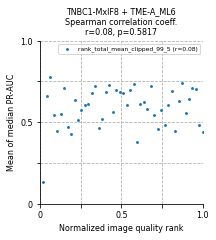

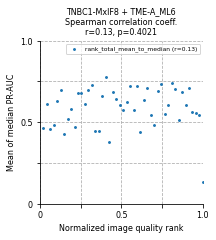

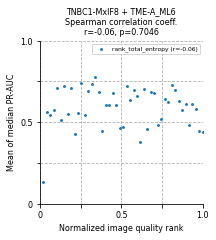

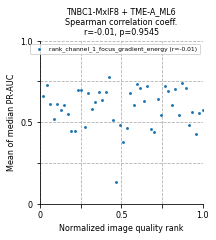

In [13]:
for metric in extra_rank_metrics_list:
    ax, corr, data_df = scatter_performance_vs_rank(
        df_scatter,
        perf_col="pr_auc",
        rank_cols=[f"rank_{metric}"],
        marker_size=3.5,
        figsize=(3.0, 3.0),
        title="TNBC1-MxIF8 + TME-A_ML6",
        show_legend=True
    )

    print("Spearman correlations:")
    for name, (r, p) in corr.items():
        print(f"  {name}: r={r:.2f}, p={p:.2g}")

    ax.figure.savefig(f"TNBC1-MxIF8_{metric}.svg", dpi=300, bbox_inches="tight")
    #data_df.drop("rank_col",axis=1).to_excel("E3a.xlsx", index=False)

In [14]:
# 1) Build entries
entries = build_single_patient_entries(
    patient_start=1,
    patient_end=30,
    test_start_id=626,
    dataset_label="TNBC2-MIBI8",
)

image_stats_csv = Path(
    "/workspace/files/CLEAR-IT/outputs/ranking/TNBC2-MIBI8/image_statistics_extended.csv"
)

In [15]:
extra_rank_metrics_list = [
        "total_mean_clipped_99_5",   # clipping @ 99.5%
        "total_mean_to_median",      # mean-to-median ratio
        "total_entropy",             # entropy
        "channel_1_focus_gradient_energy",  # focus (e.g. DAPI)
    ]
# 2) Prepare DF with extra ranking metrics
df_scatter = prepare_scatter_dataframe_single_patient_networks(
    entries,
    image_stats_csv,
    extra_rank_metrics=extra_rank_metrics_list,
)

Spearman correlations:
  rank_total_mean_clipped_99_5: r=-0.58, p=0.00084
Spearman correlations:
  rank_total_mean_to_median: r=-0.57, p=0.00094
Spearman correlations:
  rank_total_entropy: r=-0.75, p=1.4e-06
Spearman correlations:
  rank_channel_1_focus_gradient_energy: r=-0.34, p=0.068


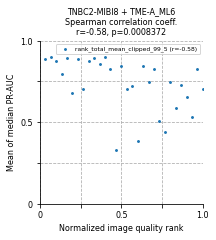

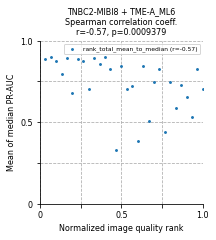

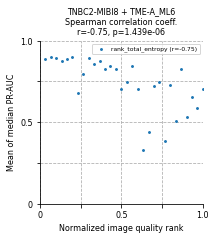

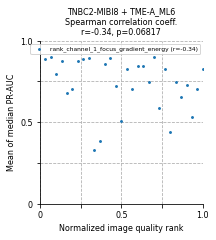

In [ ]:
for metric in extra_rank_metrics_list:
    ax, corr, data_df = scatter_performance_vs_rank(
        df_scatter,
        perf_col="pr_auc",
        rank_cols=[f"rank_{metric}"],
        marker_size=3.5,
        figsize=(3.0, 3.0),
        title="TNBC2-MIBI8 + TME-A_ML6",
        show_legend=True
    )

    print("Spearman correlations:")
    for name, (r, p) in corr.items():
        print(f"  {name}: r={r:.2f}, p={p:.2g}")

    ax.figure.savefig(f"TNBC2-MIBI8_{metric}.svg", dpi=300, bbox_inches="tight")
    #data_df.drop("rank_col",axis=1).to_excel("E3a.xlsx", index=False)

Spearman correlations:
  Normalized_Score_std: r=0.92, p=1.4e-12
  rank_total_mean_clipped_99_5: r=-0.58, p=0.00084
  rank_total_mean_to_median: r=-0.57, p=0.00094
  rank_total_entropy: r=-0.75, p=1.4e-06
  rank_channel_1_focus_gradient_energy: r=-0.34, p=0.068


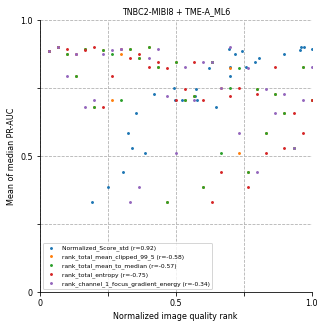

In [26]:
ax, corr, data_df = scatter_performance_vs_rank(
    df_scatter,
    perf_col="pr_auc",
    rank_cols=[
        "Normalized_Score_std",                    # legacy
        "rank_total_mean_clipped_99_5",            # clipping
        "rank_total_mean_to_median",               # mean/median
        "rank_total_entropy",                      # entropy
        "rank_channel_1_focus_gradient_energy",    # focus
    ],
    marker_size=3.5,
    figsize=(5.0, 5.0),
    title="TNBC2-MIBI8 + TME-A_ML6",
)

print("Spearman correlations:")
for name, (r, p) in corr.items():
    print(f"  {name}: r={r:.2f}, p={p:.2g}")